# 외국어 문장 판별
알파벳 언어가 어느나라 문장인지

In [1]:
# 웹에서 추출한 데이터가 한국어가 아닌 경우가 굉장히 많다.
# 머신러닝을 활용하여 외국어 글자를 읽어 들이고 어떤 언어인지 판정하는 프로그램 작성

# [이번 절에서 배울 내용]
# 해당 글자가 어떤 언어인지 판정
# 알파벳의 출현횟수 확인
# 웹서비스 응용


# 판정방법
알파벳 글자의 출현빈도로 특정

In [2]:
# 글자 데이터를 벡터로 변경해서 사용해야 함  어떻게?

# '언어' 가 다르면 알파벳의 출변빈도가 다르다 <--- 언어학적으로 알려진 사실
# '언어' 마다 자주 사용하는 표현과 단어가 다르기 때문이다.

# 이를 활용하여 'a' 부터 'z' 까지의 출현 빈도(벡터화!)를 확인하고 이를 특징으로 사용



# 데이터셋

In [4]:
# 언어별 풍부한 데이터가 있는 위키피디아 글자 사용.  

# lang.zip 파일을 풀고 lang 폴더에 보면 샘플데이터 있슴

# lang
#   ├ test     테스트데이터 8개
#   └ train    학습데이터 20개        <-- 양이 부족하긴 하지만.  작게 테스트 할 용도

#  en 영어
#  fr 프랑스어
#  id 인도네시아어
#  tl  타갈로그어   <-- 필리핀에서 많이 사용하는 언어


# import

In [5]:
from sklearn import svm, metrics
import joblib   # 학습 모델 저장  pip install joblib
import glob, os.path, re, json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image

In [6]:
import matplotlib
from matplotlib import font_manager, rc
import platform

try : 
    if platform.system() == 'Windows':
    # 윈도우인 경우
        font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
        rc('font', family=font_name)
    else:    
    # Mac 인 경우
        rc('font', family='AppleGothic')
except : 
    pass
matplotlib.rcParams['axes.unicode_minus'] = False   



# 텍스트 파일내 알파벳 출현빈도

In [7]:
#  check_freq(파일이름)  수행결과  (tuple 이다)

# ([0.07595212187159957,
#   0.012840043525571273,
#   0.04570184983677911,
#   ...
#   ...
#   0.0006528835690968443,
#   0.02002176278563656,
#   0.0004352557127312296],
#  'en')

#  data 와 label 형태다

In [8]:
base_path = r'F:\KDT2508\dataset'

In [9]:
fname = os.path.join(base_path, r'lang\train\en-1.txt')
fname

'F:\\KDT2508\\dataset\\lang\\train\\en-1.txt'

In [11]:
name = os.path.basename(fname)
name

'en-1.txt'

In [12]:
lang = name[:2]
lang

'en'

In [13]:
# 파일 읽기
with open(fname, 'r', encoding='utf-8') as f:
    text = f.read().lower()

text[:100]

'\n\n\n\nthe main henry ford museum building houses some of the classrooms for the henry ford academy\n\n\nh'

In [14]:
# 알파벳 출현 빈도 계수 

cnt = [
    text.count(chr(ord('a') + i))
    for i in range(26)
]

print(cnt)

[349, 59, 210, 212, 484, 72, 88, 201, 340, 8, 25, 247, 121, 356, 412, 76, 0, 357, 282, 370, 119, 45, 65, 3, 92, 2]


In [15]:
# 정규화 normalizing
# 각 알파벳의 출현 빈도를 확률로 계산 (0.0 ~ 1.0)

total = sum(cnt)

freq = list(map(lambda n : n / total, cnt))
print(freq)

[0.07595212187159957, 0.012840043525571273, 0.04570184983677911, 0.04613710554951034, 0.10533188248095757, 0.015669205658324265, 0.019151251360174103, 0.043743199129488576, 0.07399347116430903, 0.0017410228509249185, 0.00544069640914037, 0.05375408052230685, 0.026332970620239392, 0.07747551686615888, 0.08966267682263329, 0.016539717083786723, 0.0, 0.07769314472252448, 0.061371055495103376, 0.08052230685527748, 0.02589771490750816, 0.009793253536452665, 0.014145810663764961, 0.0006528835690968443, 0.02002176278563656, 0.0004352557127312296]


In [16]:
freq, lang

([0.07595212187159957,
  0.012840043525571273,
  0.04570184983677911,
  0.04613710554951034,
  0.10533188248095757,
  0.015669205658324265,
  0.019151251360174103,
  0.043743199129488576,
  0.07399347116430903,
  0.0017410228509249185,
  0.00544069640914037,
  0.05375408052230685,
  0.026332970620239392,
  0.07747551686615888,
  0.08966267682263329,
  0.016539717083786723,
  0.0,
  0.07769314472252448,
  0.061371055495103376,
  0.08052230685527748,
  0.02589771490750816,
  0.009793253536452665,
  0.014145810663764961,
  0.0006528835690968443,
  0.02002176278563656,
  0.0004352557127312296],
 'en')

## 위 같은 상황을 함수로 만들기 chek_frquency(fname)

In [17]:
def check_freq(fname):
    name = os.path.basename(fname)   # 파일 이름
    lang = re.match(r'^[a-z]{2,}', name).group()  # 파일 앞 2글자 추출  (문자열 slicing으로 해도 될텐데?)
    with open(fname, "r", encoding='utf-8') as f:
        text = f.read().lower()
    
    # 숫자 세기(출현빈도) 변수(cnt) 초기화
    cnt = [
        text.count(chr(i + ord('a')))
        for i in range(26)
    ]

    # 정규화 하기.. normalizing.     
    # 각 알파벳의 출현 빈도를 확률로 재계산
    total = sum(cnt)
    freq = list(map(lambda n: n / total, cnt))
    return (freq, lang)




In [19]:
print(check_freq(fname))
# 텍스트 데이터에서 각 알파벳 출현 %

([0.07595212187159957, 0.012840043525571273, 0.04570184983677911, 0.04613710554951034, 0.10533188248095757, 0.015669205658324265, 0.019151251360174103, 0.043743199129488576, 0.07399347116430903, 0.0017410228509249185, 0.00544069640914037, 0.05375408052230685, 0.026332970620239392, 0.07747551686615888, 0.08966267682263329, 0.016539717083786723, 0.0, 0.07769314472252448, 0.061371055495103376, 0.08052230685527748, 0.02589771490750816, 0.009793253536452665, 0.014145810663764961, 0.0006528835690968443, 0.02002176278563656, 0.0004352557127312296], 'en')


## 파일(들) 처리 함수 load_files(path)

In [20]:
# load_files(파일데이터 있는 경로)

# 결과 (리턴값)  dict 
# {
#    freqs :  [
#                     [0.034, 0.34, . ...  , 0.034],       <-- 알파벳의 빈도수
#                     [0.034, 0.34, . ...  , 0.034],
#                      ..
#                 ]
#    labels : ['en', 'en', 'fr', 'fr', 'id', 'id', 'tl', 'tl']
# }


In [26]:
def load_files(path):
    freqs  = []
    labels = []

    file_list = glob.glob(path)
    for fname in file_list:
        r = check_freq(fname)
        freqs.append(r[0])
        labels.append(r[1])
    return {
        'freqs' : freqs,
        'labels' : labels
    }

In [27]:
data = load_files(os.path.join(base_path, r'lang\train\*.txt'))
test = load_files(os.path.join(base_path, r'lang\test\*.txt'))

In [29]:
len(data['freqs']), len(data['labels']), len(test['freqs']), len(test['labels'])

(20, 20, 8, 8)

# 학습하기

In [30]:
clf = svm.SVC()
clf.fit(data['freqs'], data['labels'])

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# 예측하기

In [31]:
predict = clf.predict(test['freqs'])

predict

array(['en', 'en', 'fr', 'fr', 'id', 'id', 'tl', 'tl'], dtype='<U2')

In [32]:
test['labels']

['en', 'en', 'fr', 'fr', 'id', 'id', 'tl', 'tl']

# 성능평가

In [33]:
report = metrics.classification_report(test['labels'], predict)
print(report)

              precision    recall  f1-score   support

          en       1.00      1.00      1.00         2
          fr       1.00      1.00      1.00         2
          id       1.00      1.00      1.00         2
          tl       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



# 데이터 분포 시각화 

In [ ]:
"""
확률의 평균

예를 들면
첫번째 텍스트에서 'b' 가 나온 확률 0.2
두번째 텍스트에서 'b' 가 나온 확률 0.6

결국 'b' 가 나온확률은 몇 일까?

"""

In [35]:
lang_dict = {}

for idx, lbl in enumerate(data['labels']):
    print(idx, lbl)
    print(data['freqs'][idx])

0 en
[0.07595212187159957, 0.012840043525571273, 0.04570184983677911, 0.04613710554951034, 0.10533188248095757, 0.015669205658324265, 0.019151251360174103, 0.043743199129488576, 0.07399347116430903, 0.0017410228509249185, 0.00544069640914037, 0.05375408052230685, 0.026332970620239392, 0.07747551686615888, 0.08966267682263329, 0.016539717083786723, 0.0, 0.07769314472252448, 0.061371055495103376, 0.08052230685527748, 0.02589771490750816, 0.009793253536452665, 0.014145810663764961, 0.0006528835690968443, 0.02002176278563656, 0.0004352557127312296]
1 en
[0.08417789436031954, 0.019911768212710148, 0.030404196971503518, 0.038869679265529984, 0.13699773458924527, 0.017407893167998092, 0.031238821986407535, 0.02742339334684631, 0.07535471563133421, 0.0026231071896983425, 0.009777035888875641, 0.042327411470132345, 0.024204125432216526, 0.05353523309884345, 0.06879694765708835, 0.020269464647669013, 0.005484678669369262, 0.09013950160963395, 0.07165851913675927, 0.07773935853105997, 0.030642661

In [37]:
lang_dict = {}

for idx, lbl in enumerate(data['labels']):
    fq = data['freqs'][idx]

    # 기존에 lang_dict에 없었다면 추가
    if lbl not in lang_dict:
        lang_dict[lbl] = fq
        continue

    # 있었다면 해당언어 누적해서 추가
    for idx, v in enumerate(fq):
        lang_dict[lbl][idx] = (lang_dict[lbl][idx] + v ) / 2

lang_dict

{'en': [0.0739194768069211,
  0.020681128178765107,
  0.03350608129469494,
  0.03911174713526719,
  0.1310434467061397,
  0.018278876119248624,
  0.02237173917718133,
  0.05061138076323214,
  0.06999143032913047,
  0.0026036109120023895,
  0.007367475596989206,
  0.04416655190835253,
  0.025787366460804054,
  0.06338618458614578,
  0.0744698151997811,
  0.018506315265646986,
  0.0008635398475884717,
  0.068278597138231,
  0.06743078786678966,
  0.09119266371721824,
  0.02572836989124908,
  0.01045874461643153,
  0.02008086837355564,
  0.0032780118175258295,
  0.01599944721403975,
  0.0008863430770681183],
 'fr': [0.0765035930866893,
  0.012909515223940703,
  0.03658955304764068,
  0.05046404440305238,
  0.14852328629382922,
  0.012366312481167804,
  0.01613124569080846,
  0.01654464192913213,
  0.08410226872832097,
  0.0036892349824243875,
  0.0021386968318385055,
  0.06016934184823422,
  0.02853364192640589,
  0.07679474036588048,
  0.058255914298558045,
  0.0249402236312757,
  0.0054

In [40]:
df = pd.DataFrame(lang_dict, index = [chr(n + 97) for n in range(26)])
df

,en,fr,id,tl
a,0.073919,0.076504,0.171599,0.201979
b,0.020681,0.012910,0.025640,0.022360
c,0.033506,0.036590,0.007429,0.015670
d,0.039112,0.050464,0.040608,0.027269
e,0.131043,0.148523,0.081552,0.055009
f,0.018279,0.012366,0.007096,0.004491
g,0.022372,0.016131,0.040386,0.056326
h,0.050611,0.016545,0.018533,0.011768
i,0.069991,0.084102,0.092387,0.075942
j,0.002604,0.003689,0.007693,0.001994


<function matplotlib.pyplot.show(close=None, block=None)>

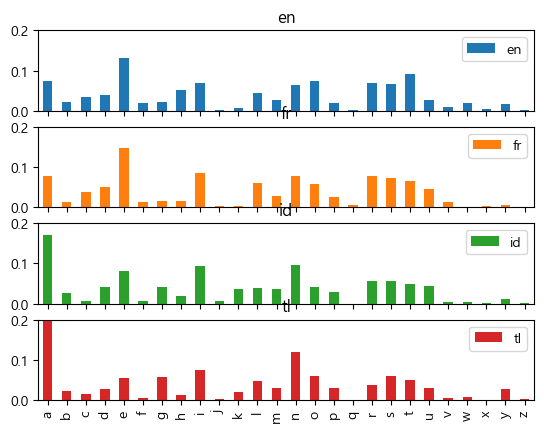

In [44]:
df.plot(kind='bar', subplots=True, ylim = (0, 0.2))
plt.show

# 학습한 모델 저장하기 

In [46]:
model_path = os.path.join(r'freq.pkl')

joblib.dump(clf, model_path)

['.freq.pkl']